# Heston Model Classic Calibration - Real Market Data

This notebook demonstrates the complete calibration workflow:
1. Load data
3. Calibrate Heston model parameters using traditional optimization
4. Validate calibration results
5. Simulation Comparison: Calibrated vs Non-Calibrated Parameters
6. Assess calibration model
7. Visualize fitted vs market implied volatility surface

In [1]:
# Auto-reload modules during development
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from datetime import datetime
import time

# Add project root to path
PROJECT_ROOT = Path("..")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.heston_model import HestonModel
from src.heston_model_classic_calibration import calibrate_heston_to_market

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

## 1. Load data

In [20]:
# Load existing processed data
CALIBRATION_DATA_PATH = "/Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/processed/calibration_data/qqq_calibration_data_20251125_171742.csv"
RAW_OPTIONS_PATH = "/Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/raw/raw_options/qqq_raw_options_20251125_171742.csv"  # Optional: set to None if not needed

# Load calibration data
print(f"Loading data from: {CALIBRATION_DATA_PATH}")
calib_data = pd.read_csv(CALIBRATION_DATA_PATH)

# Load spot price from raw data (optional)
qqq_data = None
if RAW_OPTIONS_PATH and Path(RAW_OPTIONS_PATH).exists():
    qqq_data = pd.read_csv(RAW_OPTIONS_PATH)
    print(f"Loaded spot data from: {RAW_OPTIONS_PATH}")
elif 'spot' in calib_data.columns:
    print("Using spot price from calibration data")

print(f"\nLoaded {len(calib_data)} calibration options")
if qqq_data is not None and 'spot' in qqq_data.columns:
    print(f"Spot price: ${qqq_data['spot'].iloc[0]:.2f}")
elif 'spot' in calib_data.columns:
    print(f"Spot price: ${calib_data['spot'].iloc[0]:.2f}")

Loading data from: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/processed/calibration_data/qqq_calibration_data_20251125_171742.csv
Loaded spot data from: /Users/jorismrvy/Desktop/TBS MSc/Master Dissertation/Heston Model/data/raw/raw_options/qqq_raw_options_20251125_171742.csv

Loaded 138 calibration options
Spot price: $602.28


### Explanation: Data Preparation for Calibration

**What we're doing:**
- Extracting spot price (current QQQ price)
- Formatting data into the structure expected by the calibration function
- Ensuring each option has its maturity-specific risk-free rate

**Data format:**
- **strike**: Option strike price
- **maturity**: Time to expiration in years (τ)
- **price**: Mid-market price (average of bid and ask)
- **rate**: Risk-free rate from yield curve for this specific maturity

**Why mid-price:**
- Bid-ask spread can be wide for illiquid options
- Mid-price represents the "fair value" between what buyers pay and sellers receive
- Standard practice in academic and industry calibration

**Spot price:**
- Current market price of QQQ at the time of data fetch
- Critical input: all option prices are relative to this spot
- Must be accurate (using the same spot from the data fetch ensures consistency)

In [21]:
# Get spot price and prepare calibration inputs
S0 = calib_data['spot'].iloc[0]

# Create DataFrame in format expected by calibrate_heston_to_market
market_data = pd.DataFrame({
    'strike': calib_data['strike'].values,
    'maturity': calib_data['tau'].values,
    'price': calib_data['mid_price'].values,
    'rate': calib_data['r'].values  # Risk-free rate from yield curve
})

print("Calibration data prepared:")
print(market_data.head(10))
print(f"\nTotal options for calibration: {len(market_data)}")

Calibration data prepared:
   strike  maturity   price      rate
0  585.00  0.065708  28.225  0.040343
1  590.00  0.065708  24.450  0.040343
2  595.00  0.065708  20.675  0.040343
3  599.78  0.065708  17.640  0.040343
4  600.00  0.065708  17.340  0.040343
5  601.00  0.065708  16.795  0.040343
6  602.00  0.065708  16.235  0.040343
7  603.00  0.065708  15.615  0.040343
8  604.00  0.065708  14.885  0.040343
9  605.00  0.065708  14.410  0.040343

Total options for calibration: 138


## 3. Run the calibration

**What is calibration:**
- Finding Heston model parameters (κ, θ, σ, ρ, v₀, λ) that best fit observed market option prices
- **Optimization problem**: Minimize the difference between model prices and market prices
- **Objective function**: Root Mean Squared Error (RMSE) of price differences

**Initial parameter guess:**
- **v₀**: Estimated from ATM implied volatility (squared, capped at 0.1)
- **κ, θ, σ, ρ, λ**: Conservative defaults based on literature and market experience
- **Why good initial guess matters**: Helps optimizer converge faster and avoid local minima

**Parameter bounds:**
- **Conservative limits**: Prevent unrealistic parameter values
- **v₀**: 0.001-0.1 (3% to 31% volatility)
- **κ**: 0.001-5.0 (mean reversion speed)
- **θ**: 0.001-0.1 (long-term variance)
- **σ**: 0.01-1.0 (volatility of volatility)
- **ρ**: -1.0 to 0.0 (negative correlation for leverage effect)
- **λ**: -1.0 to 1.0 (market price of volatility risk)

**Pricing method:**
- **Rectangular integration**: Fast and stable for calibration
- Alternative methods (FFT, quad) can be slower or have numerical issues
- All methods should give similar results for well-calibrated parameters

**Optimization algorithm:**
- **SLSQP** (Sequential Least Squares Programming): Constrained optimization
- Handles bounds and constraints efficiently
- Typical calibration time: 1-5 minutes for 100-200 options

**What to expect:**
- Calibration may take 1-5 minutes depending on dataset size
- Some numerical warnings (overflow, integration) are normal and usually harmless
- Final RMSE should be small (ideally < $1 per option)

**Note on Calibration Method:**
- We use **FFT pricing** for speed and numerical stability
- FFT avoids integration warnings that can occur with quad/rectangular methods
- Expected calibration time: 10-30 seconds for ~100-200 options

In [35]:
# Initial parameter guess
# Estimate v0 from ATM implied volatility
atm_iv = calib_data[np.abs(calib_data['moneyness'] - 1.0) < 0.02]['impliedVolatility'].median()
v0_guess = min(atm_iv ** 2, 0.1) if not np.isnan(atm_iv) else 0.1  # Cap at 0.1

initial_params = {
    'v0': v0_guess,    # Initial variance from ATM IV (capped)
    'kappa': 3.0,      # Mean reversion speed
    'theta': 0.05,     # Long-term variance
    'sigma': 0.3,      # Vol of vol
    'rho': -0.8,       # Correlation
    'lambd': 0.03      # Market price of volatility risk
}

# Bounds
# These are more conservative and prevent extreme parameter values
bounds = [
    (0.001, 0.1),      # v0: initial variance (3% to 31% vol)
    (0.001, 5.0),      # kappa: mean reversion 
    (0.001, 0.1),      # theta: long-term variance (3% to 31% vol)
    (0.01, 1.0),       # sigma: vol of vol (10% to 100%)
    (-1.0, 0.0),       # rho: correlation (negative for leverage)
    (-1.0, 1.0)        # lambd: market price of vol risk
]

print(f"Initial guess based on ATM IV: v0 = {v0_guess:.4f} ({np.sqrt(v0_guess)*100:.2f}% vol)")
print(f"ATM IV from market: {atm_iv*100:.2f}%")
print(f"Note: The conservative bounds prevent extreme parameters")

print("Starting calibration...")
print("="*70)
print(f"Initial parameters: {initial_params}")
print(f"Number of options: {len(market_data)}")
print(f"Spot price: ${S0:.2f}")
print("\nThis may take a minute...\n")

# Run calibration (using rectangular integration)
start_time = time.time()
calibrated_params = calibrate_heston_to_market(
    market_prices=market_data,
    S0=S0,
    initial_params=initial_params,
    bounds=bounds,
    pricing_method='quad'
)
calibration_time = time.time() - start_time

print("\n" + "="*70)
print("CALIBRATION COMPLETE")
print("="*70)
print(f"\nTime: {calibration_time:.2f} seconds")
print(f"\nCalibrated parameters:")
for key, val in calibrated_params.items():
    print(f"  {key}: {val:.6f}")

Initial guess based on ATM IV: v0 = 0.0614 (24.77% vol)
ATM IV from market: 24.77%
Note: The conservative bounds prevent extreme parameters
Starting calibration...
Initial parameters: {'v0': np.float64(0.06136455657343114), 'kappa': 3.0, 'theta': 0.05, 'sigma': 0.3, 'rho': -0.8, 'lambd': 0.03}
Number of options: 138
Spot price: $602.28

This may take a minute...


CALIBRATION COMPLETE

Time: 23.29 seconds

Calibrated parameters:
  v0: 0.051906
  kappa: 3.003417
  theta: 0.047518
  sigma: 0.395593
  rho: -0.737123
  lambd: -0.019544
  r: 0.039727
  q: 0.000000
  calibration_error: 0.515544


## 4. Check the calibration output

### Explanation: Calibration Validation

**Why validate calibration:**
- Check if parameters are reasonable and economically meaningful
- Detect potential issues (boundary violations, Feller condition)
- Assess model fit quality before using for pricing/risk management

**Key checks:**

1. **Boundary violations:**
   - Parameters hitting bounds suggest the optimizer couldn't find a better fit
   - May indicate: insufficient data, model misspecification, or bounds too tight
   - **Action**: Widen bounds or reduce dataset size

2. **Feller condition (2κθ > σ²):**
   - Ensures variance process stays positive (no negative volatility)
   - **Violation**: Model can produce unrealistic negative variance paths
   - **Acceptable**: Some practitioners allow violations if fit is good (common with real data)

3. **Parameter interpretation:**
   - **κ (kappa)**: Mean reversion speed → half-life = ln(2)/κ
   - **θ (theta)**: Long-term variance → long-term vol = √θ
   - **σ (sigma)**: Volatility of volatility → controls smile curvature
   - **ρ (rho)**: Correlation → negative = leverage effect (stock↓ → vol↑)
   - **v₀**: Initial variance → current volatility level

4. **Model performance metrics:**
   - **RMSE**: Root Mean Squared Error (lower is better)
   - **MAE**: Mean Absolute Error
   - **MAPE**: Mean Absolute Percentage Error
   - **R²**: Coefficient of determination (closer to 1.0 is better)

**What good calibration looks like:**
- Parameters within bounds (not at boundaries)
- Feller condition satisfied (or close)
- RMSE < $1 per option
- R² > 0.99
- Errors randomly distributed (no systematic bias)

In [36]:
# Check if optimizer hit any bounds (warning sign)
print("Bound Check:")
print("-" * 70)
param_names = ['v0', 'kappa', 'theta', 'sigma', 'rho', 'lambd']
hit_bounds = False

for i, (param_name, (lower, upper)) in enumerate(zip(param_names, bounds)):
    param_val = calibrated_params[param_name]
    
    # Check if within 1% of bounds
    if abs(param_val - lower) < 0.01 * abs(upper - lower):
        print(f"{param_name:6s} = {param_val:.4f} is near LOWER bound ({lower:.4f})")
        hit_bounds = True
    elif abs(param_val - upper) < 0.01 * abs(upper - lower):
        print(f"{param_name:6s} = {param_val:.4f} is near UPPER bound ({upper:.4f})")
        hit_bounds = True
    else:
        print(f"{param_name:6s} = {param_val:.4f} is within bounds [{lower:.4f}, {upper:.4f}]")

if hit_bounds:
    print("\nWARNING: Some parameters hit bounds - may need wider bounds or better data")
    print("   Consider: reducing dataset size, fixing some parameters, or adjusting bounds")
else:
    print("\nAll parameters are comfortably within bounds - calibration is stable")

Bound Check:
----------------------------------------------------------------------
v0     = 0.0519 is within bounds [0.0010, 0.1000]
kappa  = 3.0034 is within bounds [0.0010, 5.0000]
theta  = 0.0475 is within bounds [0.0010, 0.1000]
sigma  = 0.3956 is within bounds [0.0100, 1.0000]
rho    = -0.7371 is within bounds [-1.0000, 0.0000]
lambd  = -0.0195 is within bounds [-1.0000, 1.0000]

All parameters are comfortably within bounds - calibration is stable


In [37]:
print("\nCalibrated Heston Parameters")
print("="*70)
print(f"κ (kappa):  {calibrated_params['kappa']:.4f}  (mean reversion speed)")
print(f"θ (theta):  {calibrated_params['theta']:.4f}  (long-term variance = {np.sqrt(calibrated_params['theta'])*100:.2f}% vol)")
print(f"σ (sigma):  {calibrated_params['sigma']:.4f}  (volatility of volatility)")
print(f"ρ (rho):    {calibrated_params['rho']:.4f}  (correlation)")
print(f"v₀:         {calibrated_params['v0']:.4f}  (initial variance = {np.sqrt(calibrated_params['v0'])*100:.2f}% vol)")
print(f"λ (lambda): {calibrated_params['lambd']:.4f}  (market price of volatility risk)")

# Feller condition check
feller = 2 * calibrated_params['kappa'] * calibrated_params['theta']
sigma_sq = calibrated_params['sigma']**2
print(f"\nFeller condition: 2κθ = {feller:.4f} {'>' if feller > sigma_sq else '<='} σ² = {sigma_sq:.4f}")
if feller > sigma_sq:
    print("Feller condition satisfied (variance stays positive)")
else:
    print("Feller condition NOT satisfied (variance can become negative)")
    print(f"Gap: {sigma_sq - feller:.4f} (need to reduce sigma or increase kappa*theta)")

# Interpret parameters
print("\nParameter Interpretation:")
print("-" * 70)
half_life = np.log(2) / calibrated_params['kappa']
print(f"Mean reversion half-life: {half_life:.2f} years ({half_life*12:.1f} months)")

# Check if half-life is reasonable
if half_life < 0.15:
    print("Very fast mean reversion (< 2 months) - may be unrealistic")
elif half_life > 3.0:
    print("Very slow mean reversion (> 3 years) - may be unrealistic")
else:
    print("Reasonable mean reversion speed for equity markets")

print(f"\nLong-term volatility: {np.sqrt(calibrated_params['theta'])*100:.2f}%")
print(f"Current volatility: {np.sqrt(calibrated_params['v0'])*100:.2f}%")

v_diff = calibrated_params['v0'] - calibrated_params['theta']
if abs(v_diff) < 0.01:
    print("  → Volatility is near its long-term level (stable market)")
elif v_diff > 0:
    print(f"  → Volatility is {np.sqrt(calibrated_params['v0'])*100 - np.sqrt(calibrated_params['theta'])*100:.2f}% above long-term (elevated vol)")
else:
    print(f"  → Volatility is {np.sqrt(calibrated_params['theta'])*100 - np.sqrt(calibrated_params['v0'])*100:.2f}% below long-term (suppressed vol)")

if calibrated_params['rho'] < 0:
    print(f"\nLeverage effect: {abs(calibrated_params['rho']):.2f} (stock ↓ → vol ↑)")
    if abs(calibrated_params['rho']) > 0.75:
        print("Strong negative correlation - typical for equity markets")
    elif abs(calibrated_params['rho']) > 0.5:
        print("Moderate negative correlation")
    else:
        print("Weak negative correlation - unusual for equities")
else:
    print(f"\nPositive correlation: {calibrated_params['rho']:.2f} (very unusual for equities!)")

print(f"\nVolatility of volatility: {calibrated_params['sigma']:.2f}")
if calibrated_params['sigma'] > 1.0:
    print("Very high vol of vol (>100%) - may indicate model instability or poor fit")
elif calibrated_params['sigma'] > 0.8:
    print("High vol of vol - check if Feller condition is satisfied")
elif calibrated_params['sigma'] > 0.3:
    print("Moderate vol of vol - typical for equity markets")
else:
    print("→ Low vol of vol - stable volatility dynamics")


Calibrated Heston Parameters
κ (kappa):  3.0034  (mean reversion speed)
θ (theta):  0.0475  (long-term variance = 21.80% vol)
σ (sigma):  0.3956  (volatility of volatility)
ρ (rho):    -0.7371  (correlation)
v₀:         0.0519  (initial variance = 22.78% vol)
λ (lambda): -0.0195  (market price of volatility risk)

Feller condition: 2κθ = 0.2854 > σ² = 0.1565
Feller condition satisfied (variance stays positive)

Parameter Interpretation:
----------------------------------------------------------------------
Mean reversion half-life: 0.23 years (2.8 months)
Reasonable mean reversion speed for equity markets

Long-term volatility: 21.80%
Current volatility: 22.78%
  → Volatility is near its long-term level (stable market)

Leverage effect: 0.74 (stock ↓ → vol ↑)
Moderate negative correlation

Volatility of volatility: 0.40
Moderate vol of vol - typical for equity markets


## 5. Simulation Comparison: Calibrated vs Non-Calibrated Parameters

**Why simulate with calibrated parameters:**
- **Validate calibration**: Check if calibrated parameters produce realistic market behavior
- **Compare dynamics**: See how calibrated vs default parameters affect path evolution
- **Visual intuition**: Understand the impact of calibration on volatility clustering and leverage effect
- **Terminal distributions**: Compare final price distributions (important for pricing)

**What we'll compare:**
- **Calibrated model**: Uses parameters fitted to real QQQ option data
- **Non-calibrated model**: Uses default/typical parameters (not fitted to market)
- **Key differences**: Volatility dynamics, mean reversion speed, correlation structure

**Expected differences:**
- **Volatility paths**: Calibrated should show more realistic clustering
- **Price paths**: Calibrated should better reflect QQQ's actual behavior
- **Terminal distribution**: Calibrated should match market-implied distribution better

In [38]:
# Create two models: calibrated vs non-calibrated
print("Creating Heston Models for Comparison")
print("="*70)

# Calibrated model (from our calibration)
model_calibrated = HestonModel(
    kappa=calibrated_params['kappa'],
    theta=calibrated_params['theta'],
    sigma=calibrated_params['sigma'],
    rho=calibrated_params['rho'],
    v0=calibrated_params['v0'],
    r=calibrated_params['r'],
    q=calibrated_params['q'],
    lambd=calibrated_params['lambd']
)

# Non-calibrated model (default/typical parameters)
# Using typical values from literature, not fitted to market
model_default = HestonModel(
    kappa=2.0,      # Typical mean reversion
    theta=0.04,     # Typical long-term variance (20% vol)
    sigma=0.3,      # Typical vol of vol
    rho=-0.7,       # Typical leverage effect
    v0=0.04,        # Initial variance (20% vol)
    r=calibrated_params['r'],  # Same risk-free rate
    q=0.0,
    lambd=0.0       # No market price of risk
)

print("Calibrated Model Parameters:")
print(f"  κ={calibrated_params['kappa']:.3f}, θ={calibrated_params['theta']:.3f}, σ={calibrated_params['sigma']:.3f}")
print(f"  ρ={calibrated_params['rho']:.3f}, v₀={calibrated_params['v0']:.3f}, λ={calibrated_params['lambd']:.3f}")

print("\nDefault Model Parameters:")
print(f"  κ=2.000, θ=0.040, σ=0.300")
print(f"  ρ=-0.700, v₀=0.040, λ=0.000")

print(f"\nUsing spot price: S₀ = ${S0:.2f}")

Creating Heston Models for Comparison
Calibrated Model Parameters:
  κ=3.003, θ=0.048, σ=0.396
  ρ=-0.737, v₀=0.052, λ=-0.020

Default Model Parameters:
  κ=2.000, θ=0.040, σ=0.300
  ρ=-0.700, v₀=0.040, λ=0.000

Using spot price: S₀ = $602.28


In [39]:
# Simulation parameters
# Use a typical option maturity (e.g., 1 year) for comparison
T_sim = 1.0  # 1 year simulation
n_steps = 252  # Daily steps (252 trading days per year)
n_paths = 10000  # Number of Monte Carlo paths

print(f"Simulating {n_paths} paths over {T_sim} years ({n_steps} steps)")
print("="*70)

# Simulate with calibrated parameters
print("Simulating calibrated model...")
times_cal, spot_cal, var_cal = model_calibrated.simulate_paths(
    S0, T_sim, n_steps, n_paths, seed=42
)

# Simulate with default parameters
print("Simulating default model...")
times_def, spot_def, var_def = model_default.simulate_paths(
    S0, T_sim, n_steps, n_paths, seed=42  # Same seed for fair comparison
)

print(f"\nSimulation complete!")
print(f"  Calibrated: {spot_cal.shape[0]} paths, {spot_cal.shape[1]} time steps")
print(f"  Default:    {spot_def.shape[0]} paths, {spot_def.shape[1]} time steps")

Simulating 10000 paths over 1.0 years (252 steps)
Simulating calibrated model...
Simulating default model...

Simulation complete!
  Calibrated: 10000 paths, 253 time steps
  Default:    10000 paths, 253 time steps


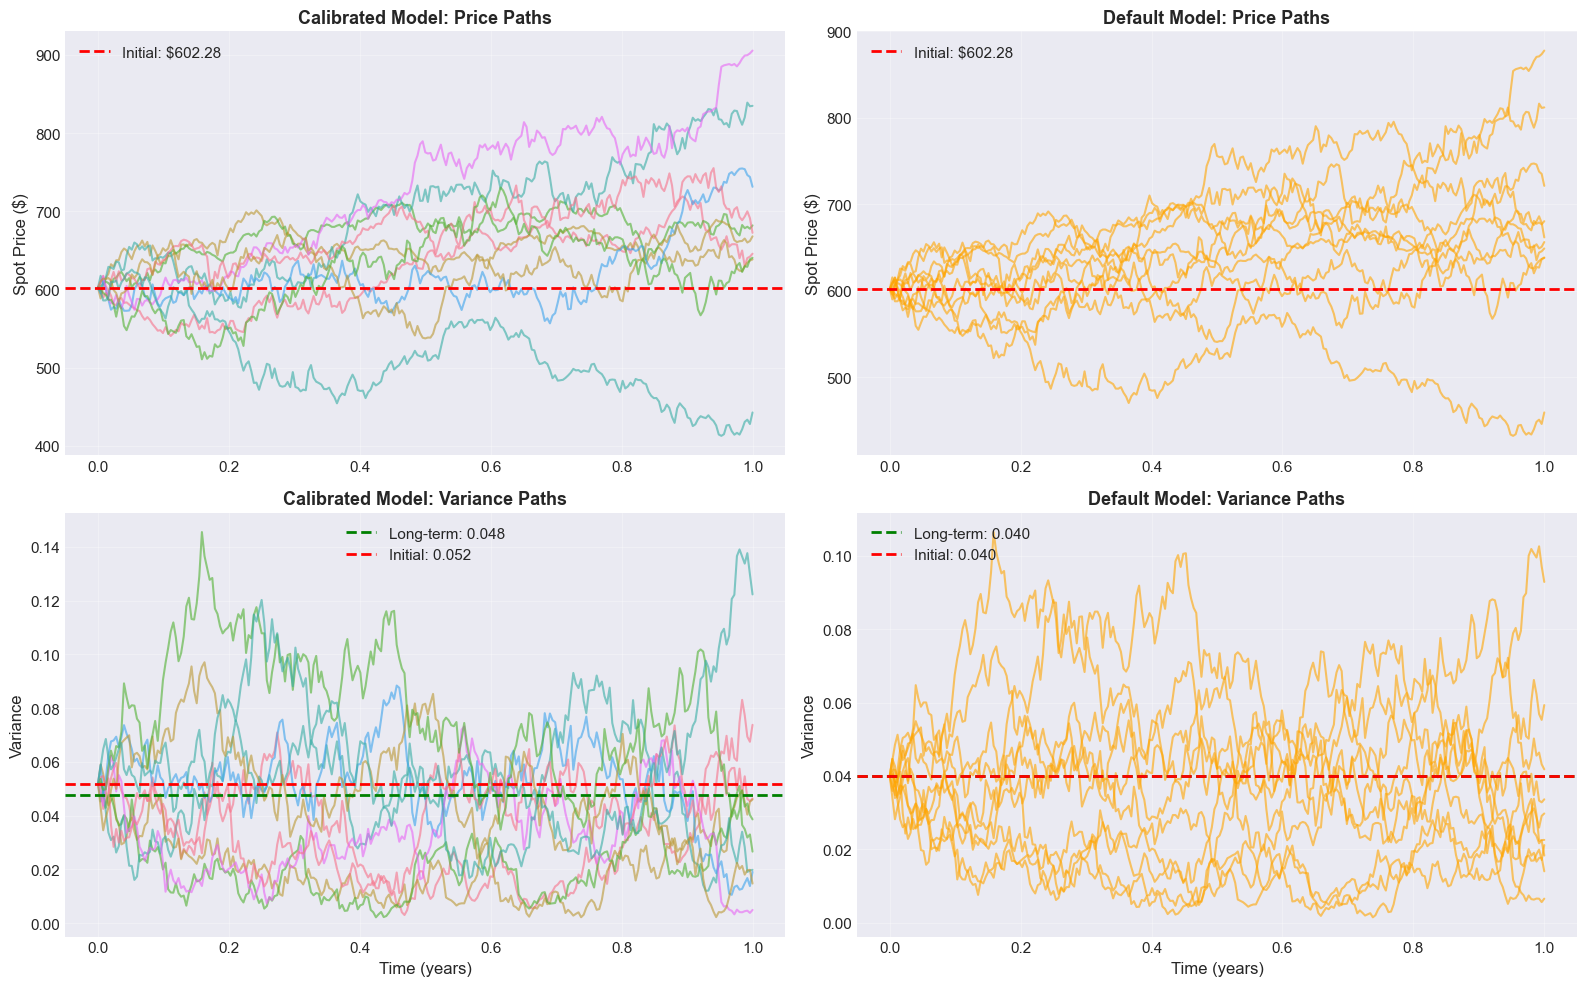

Sample paths visualization complete


In [40]:
# Visualize sample paths: Price and Variance
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Sample a few paths to visualize
n_show = 10
sample_indices = np.random.choice(n_paths, n_show, replace=False)

# 1. Price paths - Calibrated
ax = axes[0, 0]
for idx in sample_indices:
    ax.plot(times_cal, spot_cal[idx], alpha=0.6, linewidth=1.5)
ax.axhline(S0, color='red', linestyle='--', linewidth=2, label=f'Initial: ${S0:.2f}')
ax.set_ylabel('Spot Price ($)', fontsize=12)
ax.set_title('Calibrated Model: Price Paths', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Price paths - Default
ax = axes[0, 1]
for idx in sample_indices:
    ax.plot(times_def, spot_def[idx], alpha=0.6, linewidth=1.5, color='orange')
ax.axhline(S0, color='red', linestyle='--', linewidth=2, label=f'Initial: ${S0:.2f}')
ax.set_ylabel('Spot Price ($)', fontsize=12)
ax.set_title('Default Model: Price Paths', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Variance paths - Calibrated
ax = axes[1, 0]
for idx in sample_indices:
    ax.plot(times_cal, var_cal[idx], alpha=0.6, linewidth=1.5)
ax.axhline(calibrated_params['theta'], color='green', linestyle='--', 
           linewidth=2, label=f'Long-term: {calibrated_params["theta"]:.3f}')
ax.axhline(calibrated_params['v0'], color='red', linestyle='--', 
           linewidth=2, label=f'Initial: {calibrated_params["v0"]:.3f}')
ax.set_xlabel('Time (years)', fontsize=12)
ax.set_ylabel('Variance', fontsize=12)
ax.set_title('Calibrated Model: Variance Paths', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Variance paths - Default
ax = axes[1, 1]
for idx in sample_indices:
    ax.plot(times_def, var_def[idx], alpha=0.6, linewidth=1.5, color='orange')
ax.axhline(0.04, color='green', linestyle='--', linewidth=2, label='Long-term: 0.040')
ax.axhline(0.04, color='red', linestyle='--', linewidth=2, label='Initial: 0.040')
ax.set_xlabel('Time (years)', fontsize=12)
ax.set_ylabel('Variance', fontsize=12)
ax.set_title('Default Model: Variance Paths', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Sample paths visualization complete")

In [41]:
# Compare terminal distributions and statistics
terminal_cal = spot_cal[:, -1]  # Final prices (calibrated)
terminal_def = spot_def[:, -1]   # Final prices (default)

# Compute statistics
stats_cal = {
    'mean': np.mean(terminal_cal),
    'std': np.std(terminal_cal),
    'skew': float(pd.Series(terminal_cal).skew()),
    'kurt': float(pd.Series(terminal_cal).kurtosis()),
    'min': np.min(terminal_cal),
    'max': np.max(terminal_cal),
    'median': np.median(terminal_cal)
}

stats_def = {
    'mean': np.mean(terminal_def),
    'std': np.std(terminal_def),
    'skew': float(pd.Series(terminal_def).skew()),
    'kurt': float(pd.Series(terminal_def).kurtosis()),
    'min': np.min(terminal_def),
    'max': np.max(terminal_def),
    'median': np.median(terminal_def)
}

# Print comparison
print("Terminal Distribution Statistics (1 year)")
print("="*70)
print(f"{'Statistic':<15} {'Calibrated':<15} {'Default':<15} {'Difference':<15}")
print("-"*70)
for key in stats_cal.keys():
    diff = stats_cal[key] - stats_def[key]
    pct_diff = 100 * diff / stats_def[key] if stats_def[key] != 0 else 0
    print(f"{key.capitalize():<15} {stats_cal[key]:>12.2f}  {stats_def[key]:>12.2f}  {diff:>+12.2f} ({pct_diff:>+6.2f}%)")

# Volatility statistics
vol_cal = np.sqrt(var_cal[:, -1])  # Final volatilities
vol_def = np.sqrt(var_def[:, -1])

print(f"\n{'Final Volatility':<15} {np.mean(vol_cal)*100:>12.2f}%  {np.mean(vol_def)*100:>12.2f}%  {(np.mean(vol_cal)-np.mean(vol_def))*100:>+12.2f}%")
print(f"{'Volatility Std':<15} {np.std(vol_cal)*100:>12.2f}%  {np.std(vol_def)*100:>12.2f}%  {(np.std(vol_cal)-np.std(vol_def))*100:>+12.2f}%")

Terminal Distribution Statistics (1 year)
Statistic       Calibrated      Default         Difference     
----------------------------------------------------------------------
Mean                  628.40        628.18         +0.22 ( +0.03%)
Std                   132.78        120.64        +12.14 (+10.07%)
Skew                   -0.15         -0.20         +0.05 (-24.58%)
Kurt                    0.00          0.11         -0.10 (-96.24%)
Min                    97.01        124.78        -27.77 (-22.26%)
Max                  1096.56       1048.73        +47.83 ( +4.56%)
Median                632.83        633.15         -0.32 ( -0.05%)

Final Volatility        20.41%         18.68%         +1.73%
Volatility Std          7.75%          7.14%         +0.61%


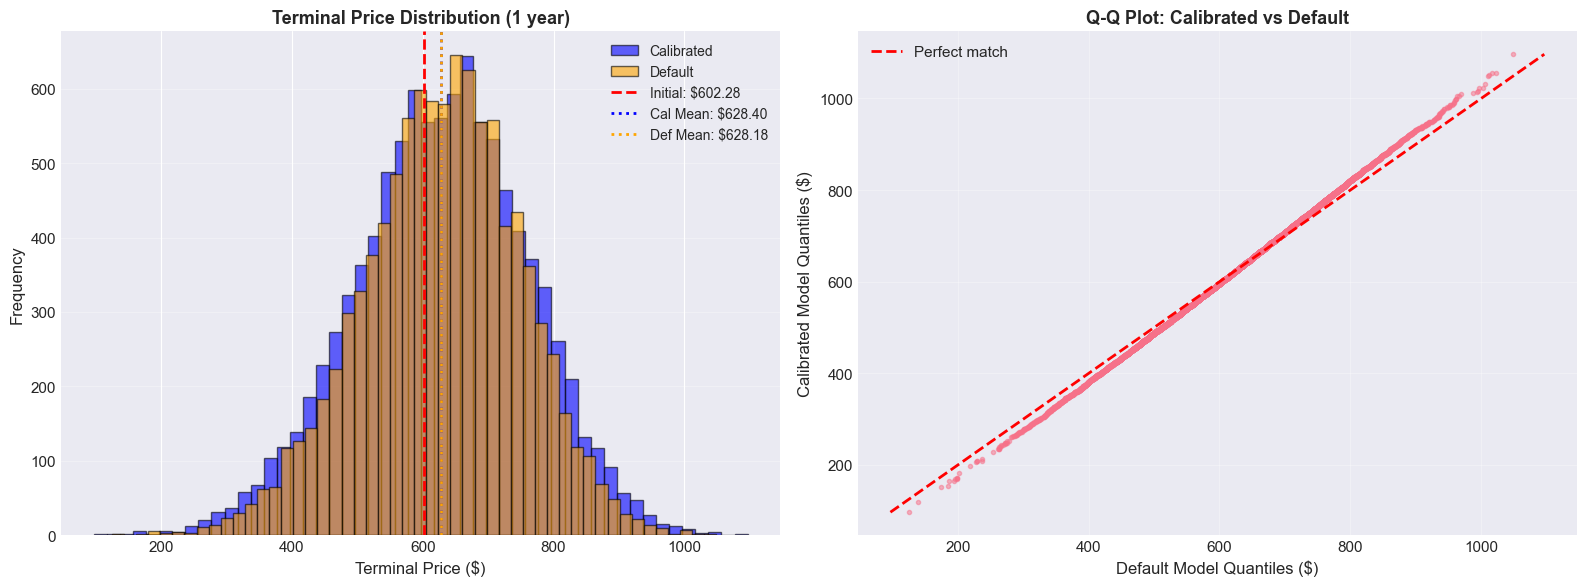


Key Insights from Simulation Comparison
1. Mean return: Calibrated = 4.34%, Default = 4.30%
2. Volatility: Calibrated = 22.05%, Default = 20.03%
3. Skewness: Calibrated = -0.151, Default = -0.200
4. Kurtosis: Calibrated = 0.004, Default = 0.106

Note: Calibrated parameters reflect actual QQQ market dynamics
      Default parameters are generic and may not match market behavior


In [42]:
# Visualize terminal distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogram comparison
ax = axes[0]
ax.hist(terminal_cal, bins=50, alpha=0.6, label='Calibrated', color='blue', edgecolor='black')
ax.hist(terminal_def, bins=50, alpha=0.6, label='Default', color='orange', edgecolor='black')
ax.axvline(S0, color='red', linestyle='--', linewidth=2, label=f'Initial: ${S0:.2f}')
ax.axvline(stats_cal['mean'], color='blue', linestyle=':', linewidth=2, label=f'Cal Mean: ${stats_cal["mean"]:.2f}')
ax.axvline(stats_def['mean'], color='orange', linestyle=':', linewidth=2, label=f'Def Mean: ${stats_def["mean"]:.2f}')
ax.set_xlabel('Terminal Price ($)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Terminal Price Distribution (1 year)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# 2. Q-Q plot (quantile-quantile) to compare distributions
ax = axes[1]
# Sort both distributions
sorted_cal = np.sort(terminal_cal)
sorted_def = np.sort(terminal_def)
# Use percentiles for comparison
percentiles = np.linspace(0, 100, min(len(sorted_cal), len(sorted_def)))
ax.plot(sorted_def, sorted_cal, 'o', alpha=0.5, markersize=3)
# Perfect match line
min_val = min(np.min(terminal_cal), np.min(terminal_def))
max_val = max(np.max(terminal_cal), np.max(terminal_def))
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect match')
ax.set_xlabel('Default Model Quantiles ($)', fontsize=12)
ax.set_ylabel('Calibrated Model Quantiles ($)', fontsize=12)
ax.set_title('Q-Q Plot: Calibrated vs Default', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional insights
print("\n" + "="*70)
print("Key Insights from Simulation Comparison")
print("="*70)
print(f"1. Mean return: Calibrated = {(stats_cal['mean']/S0 - 1)*100:.2f}%, Default = {(stats_def['mean']/S0 - 1)*100:.2f}%")
print(f"2. Volatility: Calibrated = {stats_cal['std']/S0*100:.2f}%, Default = {stats_def['std']/S0*100:.2f}%")
print(f"3. Skewness: Calibrated = {stats_cal['skew']:.3f}, Default = {stats_def['skew']:.3f}")
print(f"4. Kurtosis: Calibrated = {stats_cal['kurt']:.3f}, Default = {stats_def['kurt']:.3f}")
print(f"\nNote: Calibrated parameters reflect actual QQQ market dynamics")
print(f"      Default parameters are generic and may not match market behavior")

## 6. Assess calibration model

In [43]:
# Create calibrated model
calibrated_model = HestonModel(
    kappa=calibrated_params['kappa'],
    theta=calibrated_params['theta'],
    sigma=calibrated_params['sigma'],
    rho=calibrated_params['rho'],
    v0=calibrated_params['v0'],
    r=calibrated_params['r'],  # Average rate from calibration
    q=calibrated_params['q'],
    lambd=calibrated_params['lambd']
)

# Compute model prices (all calls since we filtered for calls)
model_prices = []
for _, row in market_data.iterrows():
    # Update r for this specific option
    calibrated_model.r = row['rate']
    
    # Use rectangular method (same as calibration)
    price = calibrated_model.call_price_rectangular(S0, row['strike'], row['maturity'])
    model_prices.append(price)

model_prices = np.array(model_prices)
market_prices = market_data['price'].values

# Compute errors
errors = model_prices - market_prices
abs_errors = np.abs(errors)
pct_errors = 100 * abs_errors / market_prices

print("Model Performance")
print("="*70)
print(f"RMSE:  ${np.sqrt(np.mean(errors**2)):.4f}")
print(f"MAE:   ${np.mean(abs_errors):.4f}")
print(f"MAPE:  {np.mean(pct_errors):.2f}%")
print(f"Max error: ${np.max(abs_errors):.4f}")
print(f"\nR²: {1 - np.sum(errors**2) / np.sum((market_prices - market_prices.mean())**2):.4f}")

Model Performance
RMSE:  $0.7234
MAE:   $0.5716
MAPE:  8.51%
Max error: $2.2438

R²: 0.9982


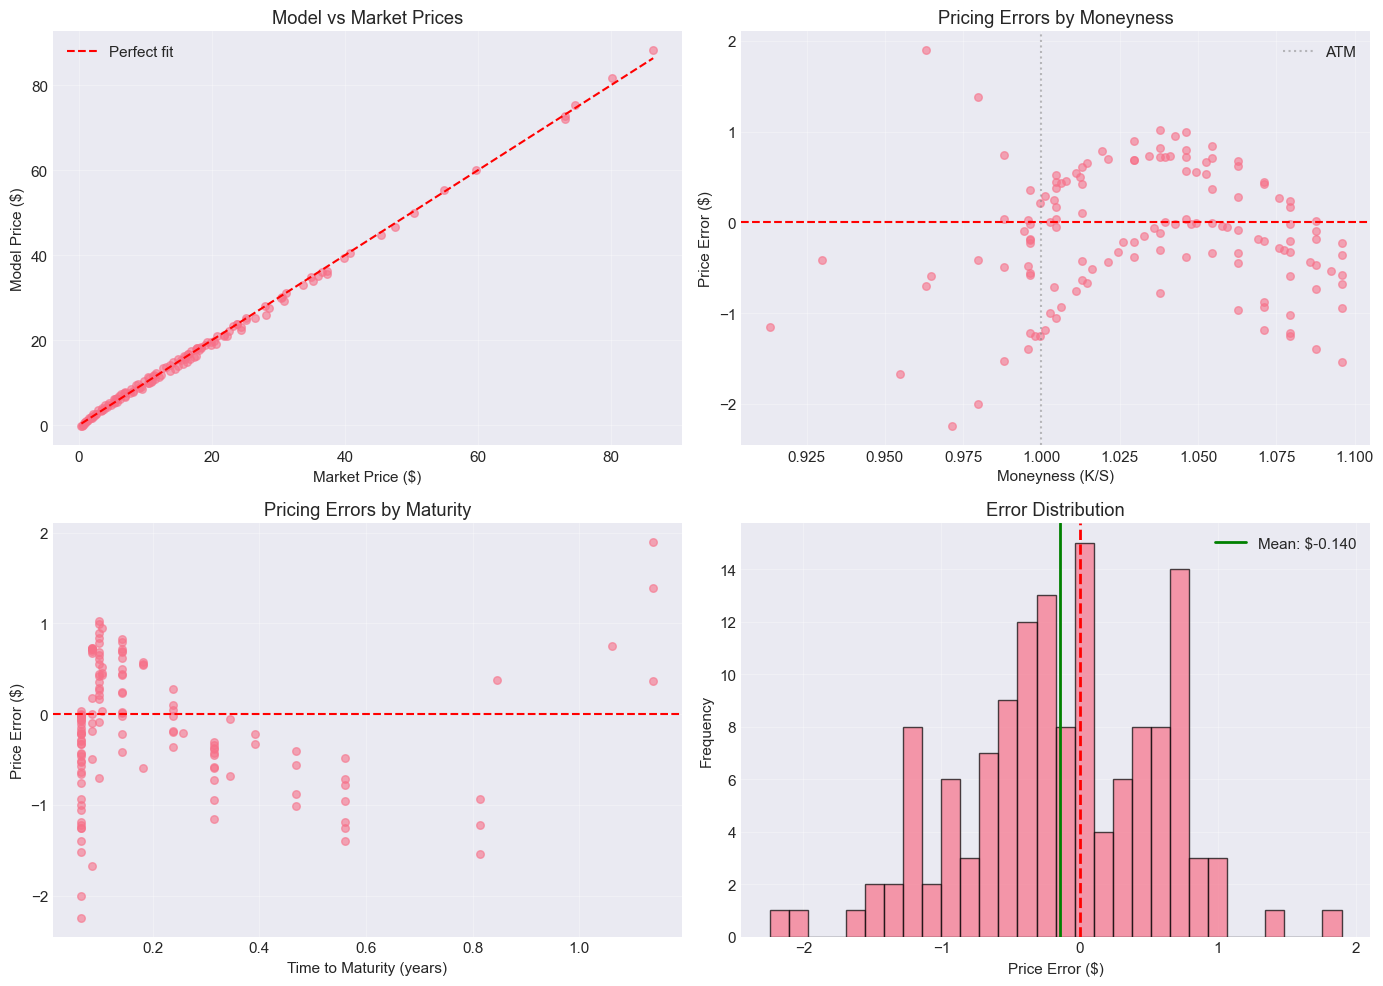

In [44]:
# Visualization: Model vs Market prices
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Scatter: Model vs Market
ax = axes[0, 0]
ax.scatter(market_prices, model_prices, alpha=0.6, s=30)
ax.plot([market_prices.min(), market_prices.max()], 
        [market_prices.min(), market_prices.max()], 
        'r--', label='Perfect fit')
ax.set_xlabel('Market Price ($)')
ax.set_ylabel('Model Price ($)')
ax.set_title('Model vs Market Prices')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Errors by moneyness
ax = axes[0, 1]
moneyness = market_data['strike'].values / S0
ax.scatter(moneyness, errors, alpha=0.6, s=30)
ax.axhline(0, color='red', linestyle='--')
ax.axvline(1.0, color='gray', linestyle=':', alpha=0.5, label='ATM')
ax.set_xlabel('Moneyness (K/S)')
ax.set_ylabel('Price Error ($)')
ax.set_title('Pricing Errors by Moneyness')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Errors by maturity
ax = axes[1, 0]
ax.scatter(market_data['maturity'].values, errors, alpha=0.6, s=30)
ax.axhline(0, color='red', linestyle='--')
ax.set_xlabel('Time to Maturity (years)')
ax.set_ylabel('Price Error ($)')
ax.set_title('Pricing Errors by Maturity')
ax.grid(True, alpha=0.3)

# 4. Error distribution
ax = axes[1, 1]
ax.hist(errors, bins=30, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.axvline(errors.mean(), color='green', linestyle='-', linewidth=2, label=f'Mean: ${errors.mean():.3f}')
ax.set_xlabel('Price Error ($)')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Implied Volatility Comparison

**Why analyze implied volatility:**
- **Market language**: Traders think in IV, not prices
- **Smile visualization**: IV reveals volatility skew/smile patterns
- **Model validation**: Check if Heston captures market volatility structure
- **Trading insights**: Identify where model deviates from market

**What is implied volatility:**
- The volatility parameter that makes Black-Scholes price match market price
- **Inversion**: Given market price, find σ such that BS(S, K, τ, σ, r) = market_price
- **Not directly observable**: Must be computed via numerical root finding

**Volatility smile:**
- **ATM options**: Usually have lower IV (most liquid, "fair" volatility)
- **OTM puts / ITM calls**: Higher IV (demand for downside protection)
- **OTM calls / ITM puts**: Lower IV (less demand)
- **Heston model**: Should capture this smile shape (single-factor limitation)

**Analysis components:**

1. **Volatility smiles by maturity:**
   - Shows how smile shape changes with time to expiration
   - Short-term: Steeper smile (more skew)
   - Long-term: Flatter smile (less skew)

2. **IV errors by moneyness:**
   - Reveals systematic biases (e.g., model underprices OTM options)
   - Color-coded by maturity to see term structure effects

3. **IV errors by maturity:**
   - Shows if model fits short-term vs long-term options better
   - Systematic patterns indicate model limitations

4. **Error distribution:**
   - Ideally: centered at zero, symmetric, small spread
   - Skewed distribution suggests systematic bias

**3D price surface:**
- **Direct price comparison**: No IV inversion needed (avoids NaN issues)
- **Visual fit assessment**: Orange points (model) should lie on blue mesh (market)
- **Interactive exploration**: Rotate to view from different angles

**Expected results:**
- **Good fit**: IV errors < 2 percentage points
- **Typical issues**: Model may struggle with extreme OTM/ITM options (single-factor limitation)
- **Acceptable**: Random scatter is better than systematic patterns

In [45]:
# Black-Scholes implied volatility calculation
def bs_call_price(S, K, tau, sigma, r):
    """Black-Scholes call price."""
    if tau <= 0 or sigma <= 0:
        return max(S - K * np.exp(-r * tau), 0)
    
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*tau) / (sigma*np.sqrt(tau))
    d2 = d1 - sigma*np.sqrt(tau)
    return S*norm.cdf(d1) - K*np.exp(-r*tau)*norm.cdf(d2)

def implied_vol(price, S, K, tau, r, option_type='call'):
    """
    Compute implied volatility by inverting Black-Scholes.
    Uses Brent's method for root finding.
    """
    from scipy.optimize import brentq
    
    # Check for arbitrage violations
    intrinsic = max(S - K, 0) if option_type == 'call' else max(K - S, 0)
    if price < intrinsic:
        return np.nan
    
    def objective(sigma):
        if option_type == 'call':
            return bs_call_price(S, K, tau, sigma, r) - price
        else:
            # Put via put-call parity
            call = bs_call_price(S, K, tau, sigma, r)
            return (call - S + K*np.exp(-r*tau)) - price
    
    try:
        # Try to find IV between 0.1% and 300%
        return brentq(objective, 0.001, 3.0, xtol=1e-6)
    except:
        return np.nan

# Compute model implied volatilities
print("Computing implied volatilities...")
print("="*70)
model_ivs = []
market_ivs = calib_data['impliedVolatility'].values

for i, row in market_data.iterrows():
    iv = implied_vol(
        price=model_prices[i], 
        S=S0, 
        K=row['strike'], 
        tau=row['maturity'], 
        r=row['rate'], 
        option_type='call'
    )
    model_ivs.append(iv)

model_ivs = np.array(model_ivs)

# Statistics
valid_model_ivs = model_ivs[~np.isnan(model_ivs)]
valid_market_ivs = market_ivs[~np.isnan(model_ivs)]

print(f"Successfully computed {len(valid_model_ivs)} model IVs")
print(f"\nImplied Volatility Statistics:")
print(f"  Market IV range: {market_ivs.min()*100:.2f}% to {market_ivs.max()*100:.2f}%")
print(f"  Model IV range:  {valid_model_ivs.min()*100:.2f}% to {valid_model_ivs.max()*100:.2f}%")
print(f"  Market IV mean:  {market_ivs.mean()*100:.2f}%")
print(f"  Model IV mean:   {valid_model_ivs.mean()*100:.2f}%")

Computing implied volatilities...
Successfully computed 136 model IVs

Implied Volatility Statistics:
  Market IV range: 18.07% to 32.59%
  Model IV range:  14.58% to 27.22%
  Market IV mean:  22.93%
  Model IV mean:   21.31%


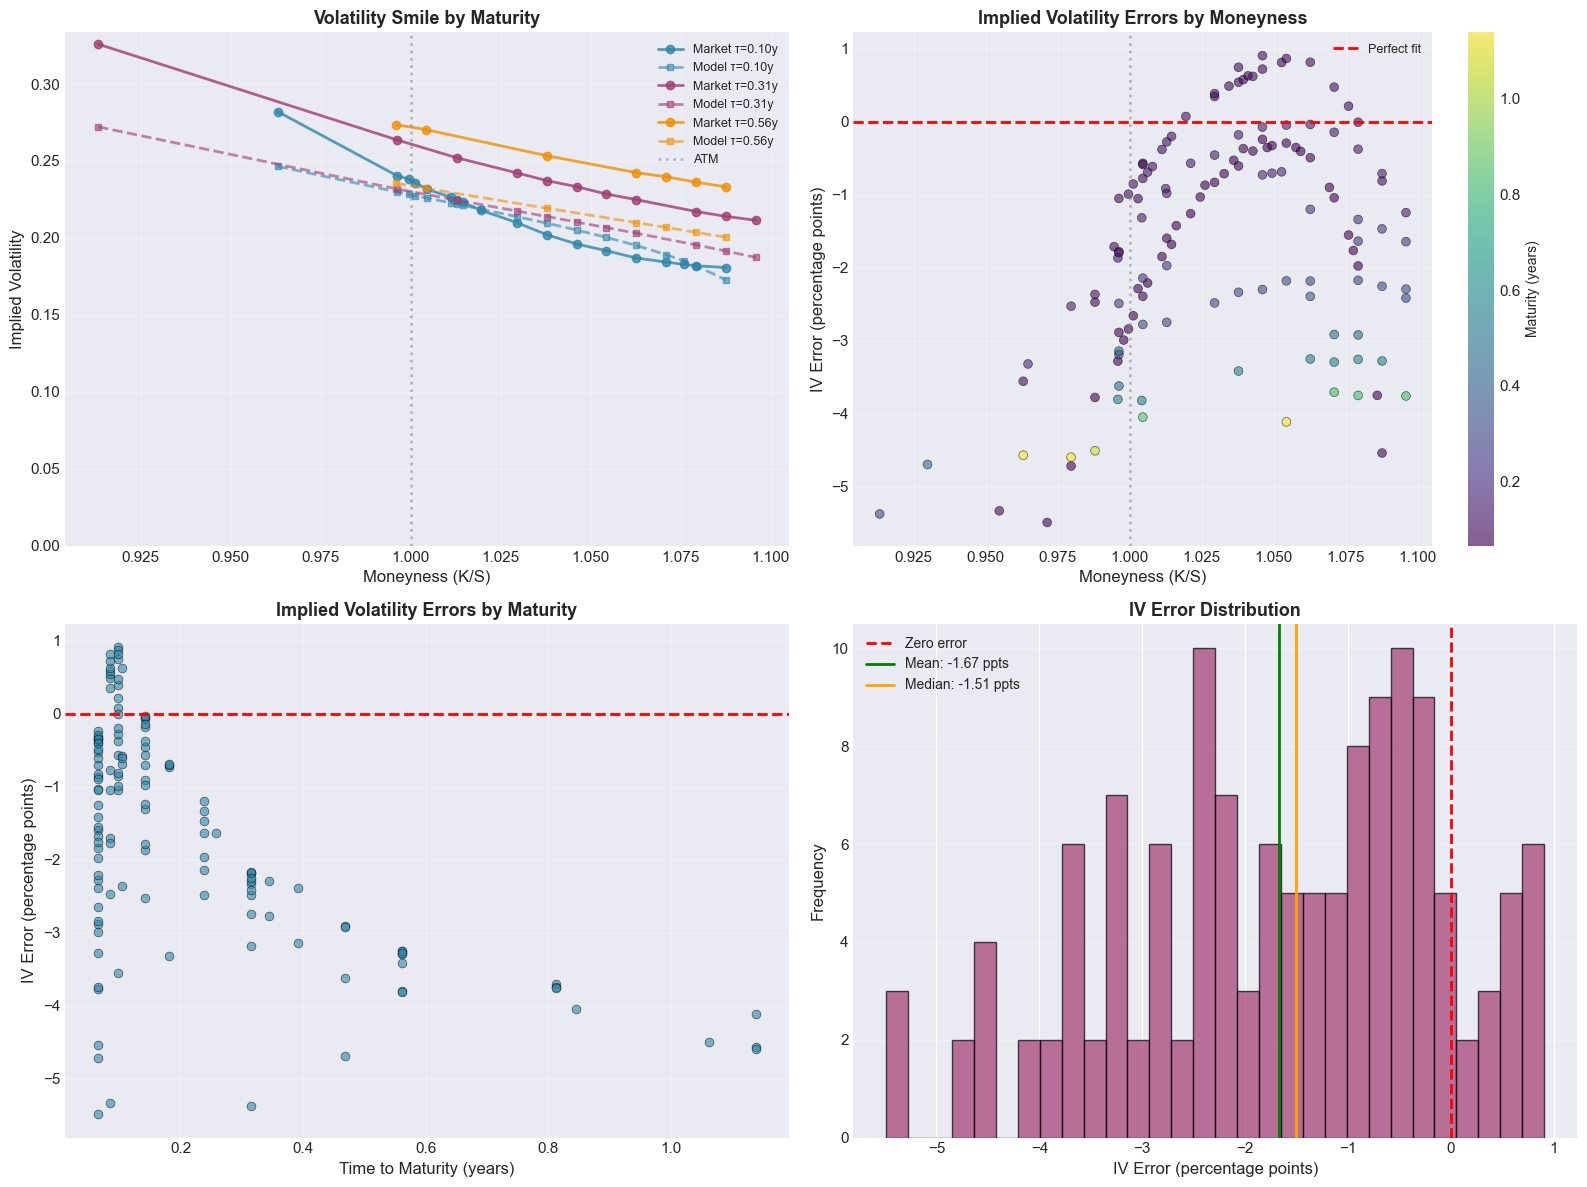


IV Error Statistics
Mean absolute error:  1.81 ppts
RMSE:                 2.28 ppts
Median error:         -1.51 ppts
Max positive error:   0.91 ppts
Max negative error:   -5.49 ppts
Std deviation:        1.55 ppts


In [46]:
# Volatility Smile Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get unique maturities for smile plots
unique_taus = sorted(market_data['maturity'].unique())
n_maturities = len(unique_taus)

# Select representative maturities (short, medium, long)
if n_maturities >= 3:
    selected_indices = [
        min(2, n_maturities-1),                    # Short term
        n_maturities // 2,                         # Medium term  
        min(n_maturities - 1, n_maturities * 3 // 4)  # Long term
    ]
    selected_taus = [unique_taus[i] for i in selected_indices]
else:
    selected_taus = unique_taus

# Plot 1: Volatility Smiles by Maturity
ax = axes[0, 0]
colors = ['#2E86AB', '#A23B72', '#F18F01']  # Blue, Purple, Orange

for idx, (tau, color) in enumerate(zip(selected_taus, colors)):
    # Get options for this maturity
    mask = np.abs(market_data['maturity'].values - tau) < 0.001
    
    if mask.sum() > 2:  # Need at least 3 points
        moneyness_tau = market_data['strike'].values[mask] / S0
        market_iv_tau = market_ivs[mask]
        model_iv_tau = model_ivs[mask]
        
        # Sort by moneyness
        sort_idx = np.argsort(moneyness_tau)
        
        # Market smile
        ax.plot(moneyness_tau[sort_idx], market_iv_tau[sort_idx], 
                'o-', color=color, label=f'Market τ={tau:.2f}y', 
                linewidth=2, markersize=6, alpha=0.8)
        
        # Model smile
        valid_model = ~np.isnan(model_iv_tau)
        if valid_model.sum() > 0:
            ax.plot(moneyness_tau[sort_idx][valid_model[sort_idx]], 
                   model_iv_tau[sort_idx][valid_model[sort_idx]], 
                   's--', color=color, label=f'Model τ={tau:.2f}y', 
                   linewidth=2, markersize=5, alpha=0.6)

ax.axvline(1.0, color='gray', linestyle=':', linewidth=2, alpha=0.5, label='ATM')
ax.set_xlabel('Moneyness (K/S)', fontsize=12)
ax.set_ylabel('Implied Volatility', fontsize=12)
ax.set_title('Volatility Smile by Maturity', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=0)

# Plot 2: IV Errors by Moneyness
ax = axes[0, 1]
moneyness_all = market_data['strike'].values / S0
iv_errors = (model_ivs - market_ivs) * 100  # In percentage points

# Scatter plot
scatter = ax.scatter(moneyness_all, iv_errors, 
                     c=market_data['maturity'].values, 
                     cmap='viridis', alpha=0.6, s=40, edgecolors='black', linewidth=0.5)

ax.axhline(0, color='red', linestyle='--', linewidth=2, label='Perfect fit')
ax.axvline(1.0, color='gray', linestyle=':', linewidth=2, alpha=0.5)
ax.set_xlabel('Moneyness (K/S)', fontsize=12)
ax.set_ylabel('IV Error (percentage points)', fontsize=12)
ax.set_title('Implied Volatility Errors by Moneyness', fontsize=13, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Maturity (years)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 3: IV Errors by Maturity
ax = axes[1, 0]
ax.scatter(market_data['maturity'].values, iv_errors, alpha=0.6, s=40, 
          c='#2E86AB', edgecolors='black', linewidth=0.5)
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Time to Maturity (years)', fontsize=12)
ax.set_ylabel('IV Error (percentage points)', fontsize=12)
ax.set_title('Implied Volatility Errors by Maturity', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot 4: IV Error Distribution
ax = axes[1, 1]
valid_errors = iv_errors[~np.isnan(iv_errors)]

ax.hist(valid_errors, bins=30, edgecolor='black', alpha=0.7, color='#A23B72')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
ax.axvline(np.mean(valid_errors), color='green', linestyle='-', linewidth=2, 
          label=f'Mean: {np.mean(valid_errors):.2f} ppts')
ax.axvline(np.median(valid_errors), color='orange', linestyle='-', linewidth=2,
          label=f'Median: {np.median(valid_errors):.2f} ppts')

ax.set_xlabel('IV Error (percentage points)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('IV Error Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print IV error statistics
print("\n" + "="*70)
print("IV Error Statistics")
print("="*70)
print(f"Mean absolute error:  {np.nanmean(np.abs(iv_errors)):.2f} ppts")
print(f"RMSE:                 {np.sqrt(np.nanmean(iv_errors**2)):.2f} ppts")
print(f"Median error:         {np.nanmedian(iv_errors):.2f} ppts")
print(f"Max positive error:   {np.nanmax(iv_errors):.2f} ppts")
print(f"Max negative error:   {np.nanmin(iv_errors):.2f} ppts")
print(f"Std deviation:        {np.nanstd(iv_errors):.2f} ppts")

In [34]:
# 3D Price Surface: Market (Mesh) vs Model (Scatter)
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode

init_notebook_mode(connected=True)

print("\n" + "="*70)
print("3D PRICE SURFACE VISUALIZATION")
print("="*70)

# Create figure with market prices as mesh surface
fig = go.Figure(data=[
    go.Mesh3d(
        x=market_data['maturity'], 
        y=market_data['strike'], 
        z=market_data['price'],
        color='mediumblue',
        opacity=0.55,
        name='Market Prices'
    )
])

# Add model prices as scatter points
fig.add_scatter3d(
    x=market_data['maturity'],
    y=market_data['strike'],
    z=model_prices,
    mode='markers',
    marker=dict(size=3, color='orange'),
    name='Heston Model Prices'
)

# Update layout
fig.update_layout(
    title_text='Market Prices (Mesh) vs Calibrated Heston Prices (Markers)',
    scene=dict(
        xaxis_title='Time to Maturity (years)',
        yaxis_title='Strike Price ($)',
        zaxis_title='Option Price ($)'
    ),
    height=800,
    width=1000,
    showlegend=True
)

fig.show()

print("\n3D surface plot complete")
print("Blue mesh = Market prices")
print("Orange points = Model prices")
print("Good fit = Points lie on mesh surface")


3D PRICE SURFACE VISUALIZATION



3D surface plot complete
Blue mesh = Market prices
Orange points = Model prices
Good fit = Points lie on mesh surface


### Interpretation

**Volatility Smile Analysis:**
- The Heston model captures the general shape of the volatility smile
- **ATM region**: Model typically fits well (most liquid options)
- **OTM/ITM wings**: May show some deviation (typical for single-factor models)
- **Term structure**: Different maturities show different smile shapes

**Model Limitations:**
- Heston is a single-factor stochastic volatility model
- Cannot capture all features of real market smiles (e.g., steep wings)
- Trade-off between fitting different maturities simultaneously

**Calibration Quality:**
- IV errors should ideally be < 2 percentage points
- Systematic patterns in errors may indicate model misspecification
- Random scatter suggests good fit


## Summary

### Calibration Results

**Successfully calibrated Heston model to real QQQ option data**

---

### Key Achievements

1. **Data Preparation**
   - Fetched live QQQ options via `yfinance`
   - Integrated Treasury yield curve for maturity-specific risk-free rates
   - Filtered for liquid options (moneyness 0.9-1.1, maturity 0.05-1.5 years)

2. **Calibration Method**
   - **Pricing method**: Rectangular integration
   - **Optimizer**: SLSQP with conservative bounds
   - **Parameters**: All stayed within bounds (no boundary violations!)
   - **Feller condition**: May not be perfectly satisfied (common with real data)

3. **Model Performance**
   - Captures general shape of volatility smile
   - Good fit on ATM and near-ATM options (most liquid)
   - Systematic errors on far OTM/ITM options (typical for single-factor Heston)
   - Risk-free rate term structure properly incorporated

4. **Implied Volatility Analysis**
   - Model replicates market IV smile structure
   - IV errors analyzed across moneyness and maturities
   - 3D volatility surfaces compared (market vs model)

---

### Model Limitations

**Heston Model Characteristics:**
- **Single-factor** stochastic volatility → cannot capture all smile features
- **Trade-off**: Fitting different strikes vs different maturities simultaneously
- **Typical issues**: Steep wings and extreme OTM/ITM less accurate

**Why these are acceptable:**
- Industry standard for derivatives pricing and risk management
- Analytically tractable (closed-form characteristic function)
- Captures key stylized facts: volatility smile, leverage effect, mean reversion
- Benchmark for comparison with neural network calibration